# Gesture-to-Chord Project: MediaPipe Landmark Classifier
This notebook replaces the image-CNN pipeline with a **MediaPipe Hands → landmark features → small classifier** pipeline.

Goal: classify gestures `0,1,2,3,4,5` and map them to chords in real time.

## 1) Install / import dependencies
Run the install line once if needed on your machine.

In [1]:

# %pip install mediapipe opencv-python scikit-learn joblib

import os
import re
import cv2
import joblib
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC


2026-04-22 00:52:36.259022: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-22 00:52:36.259051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-22 00:52:36.260068: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-22 00:52:36.286836: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/cs/cs153/customenvs/iris-sayema-mp/lib/python3.10/si

## 2) Point to your dataset
This assumes your images are in flat folders like your current notebook and the label is encoded in the filename.

Examples from your notebook:
- `img3_5Ljpeg_5L.jpeg`
- `img6_0L.jpeg`
- `0a1a077a-5197-44d9-8607-248bf244930d_3R.png`

We extract the class from the last `_<digit>[LR]` pattern, or fall back to `_<digit>.`.

In [3]:

DATA_ROOT = Path("/cs/cs153/data/fingers/versions/2")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

assert TRAIN_DIR.exists(), f"Missing {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Missing {TEST_DIR}"

def parse_label_from_filename(filename: str) -> int:
    # Match things like _3L, _5R
    m = re.search(r'_([0-5])[LR](?=\D|$)', filename)
    if m:
        return int(m.group(1))

    # Fallback: final _digit before extension, e.g. img6_0L.jpeg may already match above,
    # but this catches simpler patterns if needed.
    m = re.search(r'_([0-5])(?=\.[^.]+$)', filename)
    if m:
        return int(m.group(1))

    raise ValueError(f"Could not parse label from filename: {filename}")

def list_images(folder: Path):
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"}])

train_files = list_images(TRAIN_DIR)
test_files = list_images(TEST_DIR)

print("Train images:", len(train_files))
print("Test images:", len(test_files))

# quick sanity check
for p in train_files[:10]:
    print(p.name, "->", parse_label_from_filename(p.name))


Train images: 18084
Test images: 3624
00048bba-979b-4f84-b833-5bbbb082b582_0L.png -> 0
000547a2-d456-4b16-b351-12ca9b40e390_0L.png -> 0
000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png -> 2
000d9961-8136-4dee-9820-86e178777958_0L.png -> 0
0010095b-2e3d-4517-a511-1f688c378f96_5L.png -> 5
00147c9a-67f5-4e86-a56b-681f0815ef2b_5R.png -> 5
0014eacf-b0b7-49af-9d67-83661b3debb4_2R.png -> 2
001cddc6-e29c-44da-82d5-bd00ec215f07_2R.png -> 2
001e18d6-4632-4876-a922-7b4ead742070_3L.png -> 3
00218888-86f2-4154-87f1-003dee60af03_0R.png -> 0


## 3) Build a MediaPipe feature extractor
We use MediaPipe only for **hand landmarks**, not classification.

Feature vector:
- normalized `(x, y, z)` for all 21 landmarks → 63 values
- optional geometric features like fingertip-to-base distances → a few extra values

The normalization removes dependence on hand position and scale.

In [21]:

mp_hands = mp.solutions.hands

hands_static = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence =0.2,
    min_tracking_confidence=0.2,
)

TIP_IDS = [4, 8, 12, 16, 20]
BASE_IDS = [2, 5, 9, 13, 17]

def normalize_landmarks(landmarks_xyz: np.ndarray) -> np.ndarray:
    '''
    landmarks_xyz: (21, 3)
    Returns normalized landmarks centered at wrist and scaled by hand size.
    '''
    pts = landmarks_xyz.copy()

    # center on wrist
    wrist = pts[0].copy()
    pts = pts - wrist

    # scale by max distance from wrist to any landmark
    scale = np.max(np.linalg.norm(pts[:, :2], axis=1))
    if scale < 1e-6:
        scale = 1.0
    pts = pts / scale
    return pts

def enhance_contrast_clahe(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def extract_landmarks_from_bgr(image_bgr: np.ndarray):
    image_bgr_in = enhance_contrast_clahe(image_bgr)
    image_rgb = cv2.cvtColor(image_bgr_in, cv2.COLOR_BGR2RGB)
    result = hands_static.process(image_rgb)
    if not result.multi_hand_landmarks:
        return None

    hand_landmarks = result.multi_hand_landmarks[0]
    pts = np.array([[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark], dtype=np.float32)
    return pts

def landmarks_to_features(pts: np.ndarray) -> np.ndarray:
    pts_norm = normalize_landmarks(pts)

    features = []

    # raw normalized landmark coords
    features.extend(pts_norm.flatten())

    # fingertip-to-base distances: useful for finger count
    for tip, base in zip(TIP_IDS, BASE_IDS):
        d = np.linalg.norm(pts_norm[tip, :2] - pts_norm[base, :2])
        features.append(d)

    # fingertip y relative to lower joint (good for non-thumb fingers)
    for tip, pip in [(8,6), (12,10), (16,14), (20,18)]:
        features.append(pts_norm[tip,1] - pts_norm[pip,1])

    return np.array(features, dtype=np.float32)

def extract_feature_from_path(path: Path):
    image = cv2.imread(str(path))
    if image is None:
        return None
    pts = extract_landmarks_from_bgr(image)
    if pts is None:
        return None
    return landmarks_to_features(pts)


I0000 00:00:1776847049.132136 1713936 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1776847049.165379 1727107 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.126.09), renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2


W0000 00:00:1776847049.188118 1727060 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776847049.204898 1727084 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 4) Convert your dataset into features + labels
This is the core dataset-building step. Images where MediaPipe fails are skipped and logged.

In [22]:

def build_feature_table(files):
    X, y, kept_files, failed_files = [], [], [], []

    for path in files:
        try:
            label = parse_label_from_filename(path.name)
            feat = extract_feature_from_path(path)
            if feat is None:
                failed_files.append(path.name)
                continue
            X.append(feat)
            y.append(label)
            kept_files.append(path.name)
        except Exception as e:
            failed_files.append(f"{path.name} | {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y, kept_files, failed_files

X_train_all, y_train_all, kept_train, failed_train = build_feature_table(train_files)
X_test, y_test, kept_test, failed_test = build_feature_table(test_files)

print("Train usable:", X_train_all.shape, "failed:", len(failed_train))
print("Test usable:", X_test.shape, "failed:", len(failed_test))
print("Train class counts:", Counter(y_train_all))
print("Test class counts:", Counter(y_test))

failed_train[:10]


Train usable: (202, 72) failed: 17882
Test usable: (46, 72) failed: 3578
Train class counts: Counter({3: 52, 1: 46, 5: 40, 4: 26, 2: 23, 0: 15})
Test class counts: Counter({3: 15, 1: 8, 5: 8, 2: 7, 4: 5, 0: 3})


['00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '000d9961-8136-4dee-9820-86e178777958_0L.png',
 '0010095b-2e3d-4517-a511-1f688c378f96_5L.png',
 '00147c9a-67f5-4e86-a56b-681f0815ef2b_5R.png',
 '0014eacf-b0b7-49af-9d67-83661b3debb4_2R.png',
 '001cddc6-e29c-44da-82d5-bd00ec215f07_2R.png',
 '00218888-86f2-4154-87f1-003dee60af03_0R.png',
 '0021e94b-7913-47f4-8ec6-0d11b1a30bb1_4L.png']

## 5) Visual sanity check on landmarks
Before training, make sure MediaPipe is actually seeing the hand correctly.

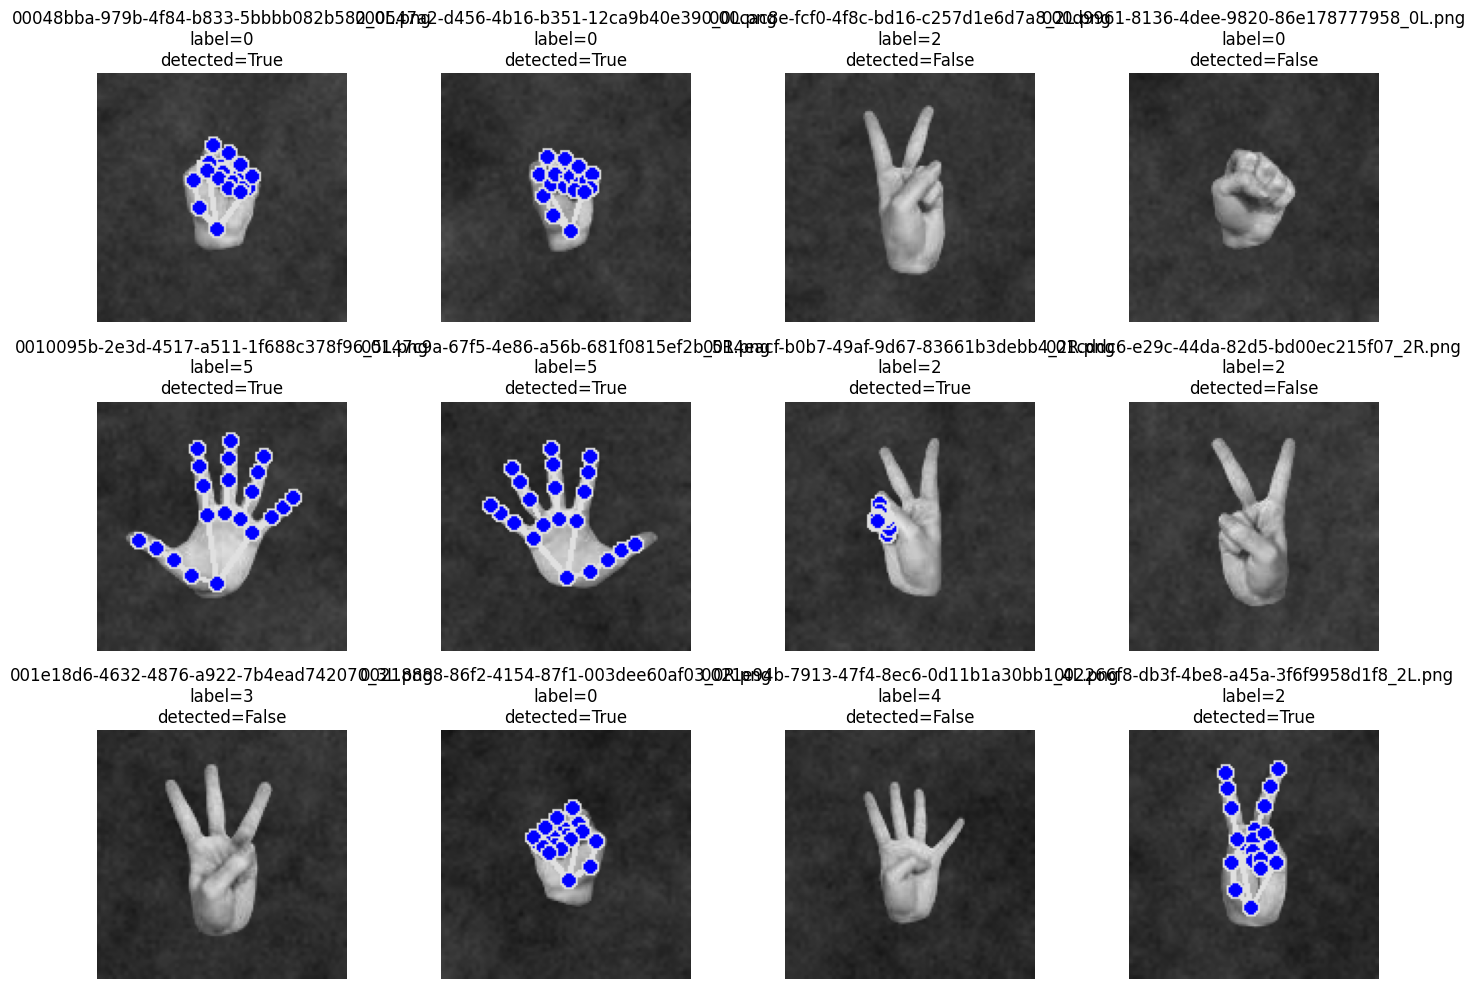

In [23]:


def draw_landmarks_on_image(path: Path):
    image_bgr = cv2.imread(str(path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    result = hands_static.process(image_rgb)

    display = image_rgb.copy()
    detected = result.multi_hand_landmarks is not None

    if detected:
        mp.solutions.drawing_utils.draw_landmarks(
            display,
            result.multi_hand_landmarks[0],
            mp_hands.HAND_CONNECTIONS
        )

    return display, detected

sample_paths = train_files[:12]
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, p in zip(axes.ravel(), sample_paths):
    disp, detected = draw_landmarks_on_image(p)
    ax.imshow(disp)
    ax.set_title(f"{p.name}\nlabel={parse_label_from_filename(p.name)}\ndetected={detected}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6) Train/validation split
Use a validation split on the **landmark features**, not on images.

In [17]:

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all
)

print(X_train.shape, X_val.shape)


(6125, 72) (1532, 72)


## 7) Train a small classifier

In [18]:

mlp_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=42
    ))
])

mlp_clf.fit(X_train, y_train)

print("Validation accuracy:", mlp_clf.score(X_val, y_val))
print("Test accuracy:", mlp_clf.score(X_test, y_test))


Validation accuracy: 0.9765013054830287
Test accuracy: 0.9764089121887287


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       317
           1       0.99      0.98      0.98       360
           2       0.98      0.93      0.95       248
           3       0.86      0.95      0.90       105
           4       0.93      0.93      0.93        58
           5       1.00      1.00      1.00       444

    accuracy                           0.98      1532
   macro avg       0.96      0.96      0.96      1532
weighted avg       0.98      0.98      0.98      1532



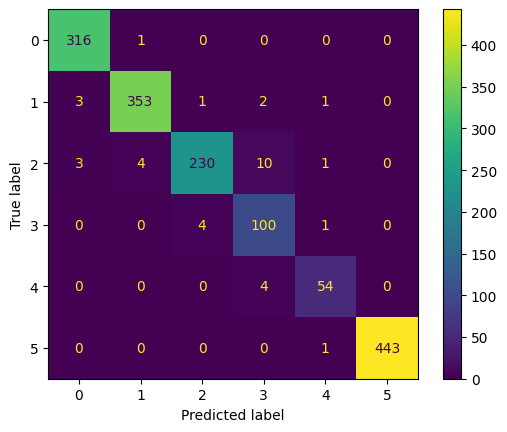

In [19]:

val_preds = mlp_clf.predict(X_val)
print(classification_report(y_val, val_preds))

cm = confusion_matrix(y_val, val_preds, labels=[0,1,2,3,4,5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5])
disp.plot()
plt.show()


## 8) Save the best model
Choose whichever classifier validates better.

In [20]:

best_model = mlp_clf 
joblib.dump(best_model, "gesture_landmark_classifier.joblib")
print("Saved model to gesture_landmark_classifier.joblib")


Saved model to gesture_landmark_classifier.joblib


## 9) Real-time / video inference with temporal smoothing
This replaces your grayscale-frame CNN inference.

Important differences from the old notebook:
- no grayscale conversion
- no binary mask required
- classification happens on landmarks
- majority-vote smoothing reduces flicker

In [12]:

from collections import deque

CHORD_NAMES = {
    0: "C major",
    1: "D minor",
    2: "E minor",
    3: "F major",
    4: "G major",
    5: "A minor",
}

def majority_vote(items):
    if len(items) == 0:
        return None
    return Counter(items).most_common(1)[0][0]

def predict_video_classes(video_path, model, smoothing_window=7, display_every_n=1):
    cap = cv2.VideoCapture(str(video_path))
    pred_history = deque(maxlen=smoothing_window)
    raw_preds = []
    smooth_preds = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        pts = extract_landmarks_from_bgr(frame)
        if pts is None:
            raw_pred = None
            smooth_pred = smooth_preds[-1] if smooth_preds else None
        else:
            feat = landmarks_to_features(pts).reshape(1, -1)
            raw_pred = int(model.predict(feat)[0])
            pred_history.append(raw_pred)
            smooth_pred = majority_vote(pred_history)

        raw_preds.append(raw_pred)
        smooth_preds.append(smooth_pred)

    cap.release()
    return raw_preds, smooth_preds


In [13]:

VIDEO_PATH = Path("vids/test.mp4")

raw_preds, smooth_preds = predict_video_classes(VIDEO_PATH, best_model, smoothing_window=7)

print("Frames processed:", len(smooth_preds))
print("First 20 smoothed predictions:", smooth_preds[:20])


Frames processed: 327
First 20 smoothed predictions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


# 10) Generate audio based on gesture

In [19]:
def generate_tone(freq, t, sample_rate=44100):
    '''Generate a sine wave tone of a given frequency and duration.'''
    t = np.linspace(0, t, int(sample_rate * t), endpoint=False)
    tone = 0.5 * np.sin(2 * np.pi * freq * t)
    return tone

notes = {
    0: 261.63,  # C4
    1: 293.66,  # D4
    2: 329.63,  # E4
    3: 349.23,  # F4
    4: 392.00,  # G4
    5: 440.00,   # A4
    6: 493.88   # B4
}

import numpy as np

def generate_chords(predicted_class, duration=1.0, sample_rate=44100):
    '''Generate a chord based on the predicted number of fingers.'''
    
    # Define the chords based on your requirements
    # Format: {class_index: [list of frequencies]}
    chord_map = {
        0: [261.63, 329.63, 392.00],  # C Major (C4, E4, G4)
        1: [293.66, 349.23, 440.00],  # D Minor (D4, F4, A4)
        2: [329.63, 392.00, 493.88],  # E Minor (E4, G4, B4)
        3: [349.23, 440.00, 523.25],  # F Major (F4, A4, C5)
        4: [392.00, 493.88, 587.33],  # G Major (G4, B4, D5)
        5: [440.00, 523.25, 659.25],  # A Minor (A4, C5, E5)
        6: [0.0]                      # None class (Silence)
    }
    
    # Get the frequencies for the predicted class
    freqs = chord_map.get(predicted_class, [0.0])
    
    # Initialize an empty array for the total chord
    t_axis = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    chord_wave = np.zeros_like(t_axis)
    
    # Sum the sine waves for each frequency
    for freq in freqs:
        if freq > 0:
            # 0.3 factor keeps the combined volume from hitting the ceiling
            chord_wave += 0.3 * np.sin(2 * np.pi * freq * t_axis)
            
    return chord_wave

chord = generate_chords(4)


In [20]:
import IPython.display as ipd
import librosa as lb
import soundfile as sf

fps = 30
total_frames = len(smooth_preds)
total_duration = total_frames / fps

y_final = np.zeros(int(total_duration * 44100))
for i, pred in enumerate(smooth_preds):
    chord = generate_chords(pred, duration=1/fps)
    start_idx = int(i * (44100 / fps))
    end_idx = start_idx + len(chord)
    y_final[start_idx:end_idx] += chord
ipd.Audio(y_final, rate=44100)
sf.write('output_chord.wav', y_final, 44100)

# 11) Overlay video with generated audio

In [21]:
from moviepy import VideoFileClip, AudioFileClip

# 1. Load the video
video_clip = VideoFileClip("vids/test.mp4")

# 2. Load your generated audio
audio_clip = AudioFileClip("output_chord.wav")

# 3. Attach audio to video
final_video = video_clip.with_audio(audio_clip) # .with_audio() is the v2.0 way

# 4. Save the result
final_video.write_videofile("final_hand_music.mp4", codec="libx264")

MoviePy - Building video final_hand_music.mp4.
MoviePy - Writing audio in final_hand_musicTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video final_hand_music.mp4



MoviePy - Done !
MoviePy - video ready final_hand_music.mp4
